In [1]:
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import mpl_toolkits.axisartist.floating_axes as floating_axes
import mpl_toolkits.axisartist.angle_helper as angle_helper
from mpl_toolkits.axisartist.grid_finder import MaxNLocator
from matplotlib.transforms import Affine2D

from astropy import constants as const
from astropy.table import Table

## Data files

In [2]:
MaNGA_filename = '../RotationCurves/spirals/Pipe3D-master_file_vflag_10_smooth2p27.txt'

DR7_filename = '/Users/kellydouglass/Documents/Drexel/Research/Data/kias1033_5_P-MJD-F_MPAJHU_ZdustOS_stellarMass_BPT_SFR_NSA_vflag.txt'

void_filename = '/Users/kellydouglass/Documents/Research/Voids/VoidFinder/void_catalogs/SDSS/python_implementation/vollim_dr7_cbp_102709_comoving_maximal.txt'


## Import data

In [3]:
# MaNGA galaxy catalog
MaNGA_galaxies = Table.read(MaNGA_filename, format='ascii.ecsv')

# Background galaxy catalog (SDSS DR7)
dr7_galaxies = Table.read(DR7_filename, format='ascii.commented_header', 
                          include_names=['ra', 'dec', 'redshift', 'Rgal', 'vflag'])

# Void catalog (detected voids, output of voidfinder)
voids = Table.read(void_filename, format='ascii.commented_header')

In [4]:
# Keep only those MaNGA galaxies that are included in analysis
boolean = np.logical_or(MaNGA_galaxies['curve_used'] == 'non', 
                        MaNGA_galaxies['curve_used'] == 'none')
good_MaNGA = MaNGA_galaxies[np.logical_not(boolean)]

## Convert redshift to distance
Going to plot $cz$ in km/s

In [5]:
c = const.c.to('km/s').value

good_MaNGA['cz'] = c*good_MaNGA['NSA_redshift']
dr7_galaxies['cz'] = c*dr7_galaxies['redshift']

print(min(good_MaNGA['cz']), max(good_MaNGA['cz']))
print(min(dr7_galaxies['Rgal']), max(dr7_galaxies['Rgal']))

152.00023 43024.477
0.02 1333.67


## Function to set up axes

Following matplotlib demo : https://matplotlib.org/examples/axes_grid/demo_floating_axes.html

In [6]:
def setup_axes3(fig, rect, ra0, ra1, cz0, cz1):
    
    # rotate a bit for better orientation
    tr_rotate = Affine2D().translate(-90, 0)
    
    # scale degree to radians
    tr_scale = Affine2D().scale(np.pi/180, 1)

    tr = tr_rotate + tr_scale + mpl.projections.PolarAxes.PolarTransform()
    
    grid_locator1 = angle_helper.LocatorHMS(4)
    tick_formatter1 = angle_helper.FormatterHMS()
    
    grid_locator2 = MaxNLocator(3)
    
    grid_helper = floating_axes.GridHelperCurveLinear(tr, extremes=(ra0, ra1, cz0, cz1),
                                                      grid_locator1=grid_locator1,
                                                      grid_locator2=grid_locator2,
                                                      tick_formatter1=tick_formatter1,
                                                      tick_formatter2=None)

    ax1 = floating_axes.FloatingSubplot(fig, rect, grid_helper=grid_helper)
    fig.add_subplot(ax1)
    
    # adjust axis
    ax1.axis['left'].set_axis_direction('bottom')
    
    ax1.axis['right'].set_axis_direction('top')
    
    ax1.axis['bottom'].set_visible(False)
    
    ax1.axis['top'].set_axis_direction("bottom")
    ax1.axis['top'].toggle(ticklabels=True, label=True)
    ax1.axis['top'].major_ticklabels.set_axis_direction("top")
    ax1.axis['top'].label.set_axis_direction("top")
    
    #ax1.axis['left'].major_ticklabels.set_axis_direction('right')
    ax1.axis["left"].label.set_text("cz [km/s]")
    
    aux_ax = ax1.get_aux_axes(tr)

    aux_ax.patch = ax1.patch  
    ax1.patch.zorder = 0.9  

    return ax1, aux_ax

## Wedge plot

In [7]:
# 'd' is declination and 's' is the thickness of the declination slice
# Vary 'd' and 's' to get difference slices.
d,s = 26,2

# slice center, can use this for analysis since the slice thickness is very small.
slice_= d + 0.5*s


################################################################################
# Remove galaxies outside declination range
#-------------------------------------------------------------------------------
MaNGA_dec_cut = np.logical_and(good_MaNGA['NSA_DEC'] > d, 
                               good_MaNGA['NSA_DEC'] <= d+s)
MaNGA_dec_slice = good_MaNGA[MaNGA_dec_cut]

dr7_dec_cut = np.logical_and(dr7_galaxies['dec'] > d, 
                             dr7_galaxies['dec'] <= d+s)
dr7_dec_slice = dr7_galaxies[dr7_dec_cut]
################################################################################


################################################################################
# Remove galaxies outside distance range
#-------------------------------------------------------------------------------
cz_min, cz_max = 0, 30000

MaNGA_dist_boolean = np.logical_and(MaNGA_dec_slice['cz'] > cz_min, 
                                    MaNGA_dec_slice['cz'] <= cz_max)
MaNGA_sample = MaNGA_dec_slice[MaNGA_dist_boolean]

dr7_dist_boolean = np.logical_and(dr7_dec_slice['cz'] > cz_min, 
                                  dr7_dec_slice['cz'] <= cz_max)
dr7_sample = dr7_dec_slice[dr7_dist_boolean]
################################################################################


################################################################################
# Voids that intersect the slice
#-------------------------------------------------------------------------------
dec_intersect_cut = np.sin(np.abs(slice_ - voids['dec'])*np.pi/180)*voids['r'] <= voids['radius']
void_sample = voids[dec_intersect_cut]

# Radius of void at intersection
void_sample['radius_intersect'] = np.sqrt(void_sample['radius']**2 
                                          - (np.sin(np.abs(slice_ - void_sample['dec'])*np.pi/180)*void_sample['r'])**2)
################################################################################

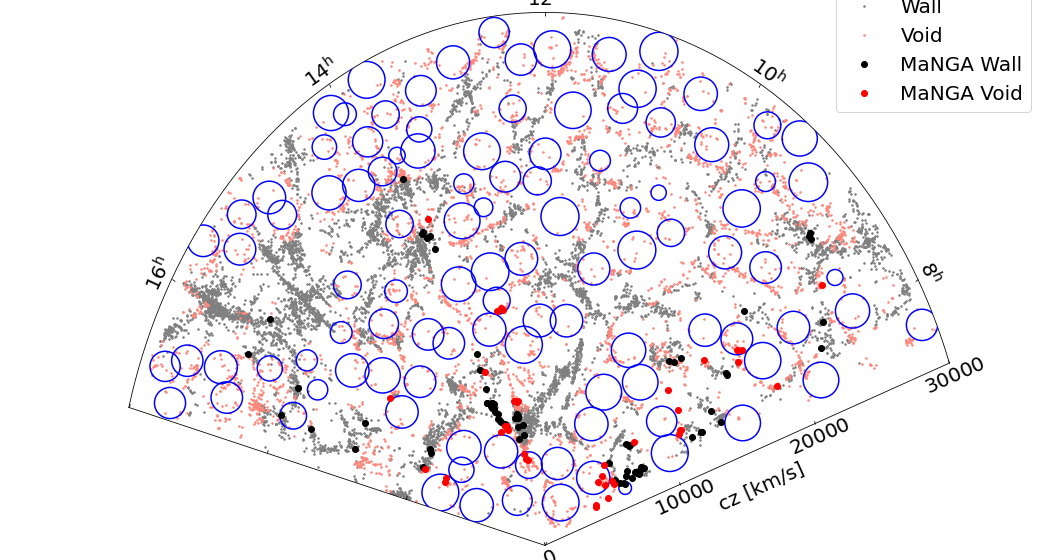

In [9]:
fig = plt.figure(figsize=(15,10))

# Range of RA to use in plot
ra_min, ra_max = 110, 255

ax, aux_ax = setup_axes3(fig, 111, ra_min, ra_max, cz_min, cz_max)


# Background galaxies
aux_ax.plot(dr7_sample['ra'][dr7_sample['vflag'] == 0], 
            dr7_sample['cz'][dr7_sample['vflag'] == 0], 
            '.', c='0.5', ms=3, zorder=1, label='Wall')
            #'.', c='0.5', zorder=1, label='Wall')
aux_ax.plot(dr7_sample['ra'][dr7_sample['vflag'] == 1], 
            dr7_sample['cz'][dr7_sample['vflag'] == 1], 
            '.', c=(1,135/255,123/255), ms=3, zorder=2, label='Void')
            #'.', c=(1,135/255,123/255), zorder=2, label='Void')

# MaNGA galaxies
aux_ax.plot(MaNGA_sample['NSA_RA'][MaNGA_sample['vflag'] == 0], 
            MaNGA_sample['cz'][MaNGA_sample['vflag'] == 0], 
            'ko', zorder=4, label='MaNGA Wall')
aux_ax.plot(MaNGA_sample['NSA_RA'][MaNGA_sample['vflag'] == 1], 
            MaNGA_sample['cz'][MaNGA_sample['vflag'] == 1], 
            'ro', zorder=5, label='MaNGA Void')

# Voids

aux_ax.scatter(void_sample['ra'], void_sample['r']*100, edgecolors='b', 
               s=void_sample['radius_intersect']*100, facecolors='none', 
               linewidth=1.5, zorder=3)

ax.legend(bbox_to_anchor=(1.1, 1.05))

mpl.rc('font', size=20)

plt.tight_layout();

#plt.savefig('MaNGA_wedge_test.eps', format='eps', dpi=300)


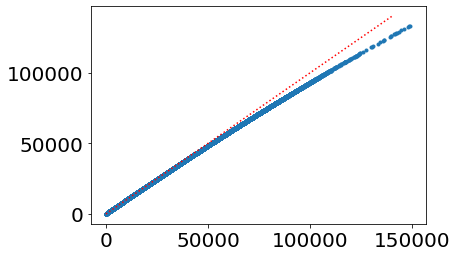

In [11]:
plt.figure()
plt.plot(dr7_galaxies['cz'], dr7_galaxies['Rgal']*100, '.')
plt.plot([0,140000],[0,140000], 'r:');